In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df= pd.read_csv('data/student_info.csv')

In [3]:
df.head()   


,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [4]:
df.tail()


,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [5]:
df.shape

(200, 2)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
df.describe()


,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


In [8]:
df.columns

Index(['study_hours', 'student_marks'], dtype='object')

In [13]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [14]:
df[df.isnull().any(axis=1)]

,study_hours,student_marks
2,NaN,78.68
31,NaN,76.14
96,NaN,75.39
122,NaN,76.83
188,NaN,77.27


In [16]:
df['study_hours'].fillna(df['study_hours'].mean(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13936\392308505.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['study_hours'].fillna(df['study_hours'].mean(), inplace=True)


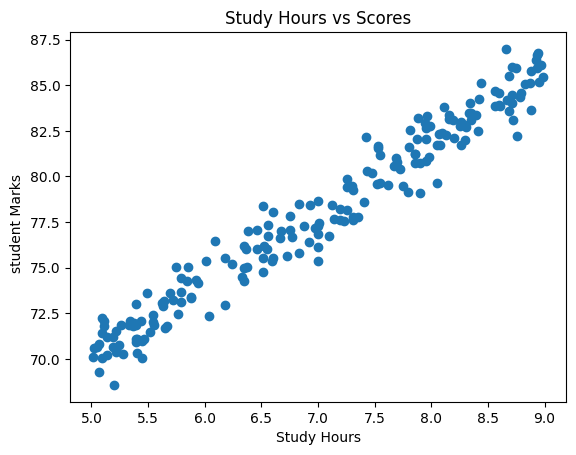

In [18]:
plt.scatter(x=df.study_hours, y=df.student_marks)
plt.xlabel('Study Hours')
plt.ylabel('student Marks   ')    
plt.title('Study Hours vs Scores')
plt.show()

In [ ]:
X = df.drop('student_marks', axis=1)
y = df.drop['student_marks', axis=0]
print(X.shape  )
print(y.shape)
print(X)
from sklearn.model_selection import train_test_split

(200, 1)
(200,)
     study_hours
0       6.830000
1       6.560000
2       6.995949
3       5.670000
4       8.670000
..           ...
195     7.530000
196     8.560000
197     8.940000
198     6.600000
199     8.350000

[200 rows x 1 columns]


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("shape of X_train:", X_train.shape)
print("shape of X_test:", X_test.shape)
print("shape of y_train:", y_train.shape)
print("shape of y_test:", y_test.shape)

(160, 1) (40, 1) (160,) (40,)
shape of X_train: (160, 1)
shape of X_test: (40, 1)
shape of y_train: (160,)
shape of y_test: (40,)


In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.942580760104548
MSE: 1.4540976212481111


In [32]:
model.coef_
model.intercept_

np.float64(50.43835070056993)

In [33]:
model.intercept_

np.float64(50.43835070056993)

In [ ]:
model.intercept_

np.float64(66.14)

In [39]:
y_pred= model.predict(X_test)
y_pred

array([74.35016819, 76.15631533, 82.36003809, 80.00419401, 75.48882617,
       73.17224615, 82.83120691, 70.81640206, 71.60168343, 74.70354481,
       81.29990825, 84.44103371, 71.56241936, 70.42376138, 85.26557914,
       73.17224615, 73.01518988, 82.16371775, 76.58822008, 70.34523325,
       84.55882591, 75.41029803, 83.02752725, 81.45696453, 71.83726783,
       71.99432411, 77.45202958, 82.87047098, 84.79441032, 77.25570924,
       76.94159669, 83.459432  , 84.55882591, 74.15384785, 71.60168343,
       78.82627196, 83.14531946, 70.62008172, 81.33917232, 70.50228952])

In [41]:
print(y_pred.shape)
print(y_test.shape)


(40,)
(40,)


In [43]:
import joblib
joblib.dump(model, 'student_marks_model.pkl')

['student_marks_model.pkl']

In [44]:
model=joblib.load('student_marks_model.pkl')

In [46]:
model.predict([[5]])[0]

np.float64(70.07038476812897)